<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Actividad 1 - Interpretabilidad de modelos
### Análisis de datos II - 4B2026

### Alumno: Fontanari Federico


In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

import shap

import kagglehub
import os

RANDOM_STATE = 14
pd.set_option("display.max_columns", None)

## 1. Carga y exploracion breve del dataset

In [ ]:
path = kagglehub.dataset_download("arnabchaki/data-science-salaries-2023")
df = pd.read_csv(os.path.join(path, "ds_salaries.csv"))

100%|██████████| 25.4k/25.4k [00:00<00:00, 31.3MB/s]

Extracting files...


In [ ]:
print(df.shape)
df.head()

(3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [ ]:
df.info()
print()
print("Nulos por columna:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB

Nulos por columna:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remot

In [ ]:
#Variables Numericas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,3755.0,2022.373635,0.691448,2020.0,2022.0,2022.0,2023.0,2023.0
salary,3755.0,190695.571771,671676.500508,6000.0,100000.0,138000.0,180000.0,30400000.0
salary_in_usd,3755.0,137570.389880,63055.625278,5132.0,95000.0,135000.0,175000.0,450000.0
remote_ratio,3755.0,46.271638,48.589050,0.0,0.0,0.0,100.0,100.0


In [ ]:
#Variables categoricas
df.describe(include='O').T

,count,unique,top,freq
experience_level,3755,4,SE,2516
employment_type,3755,4,FT,3718
job_title,3755,93,Data Engineer,1040
salary_currency,3755,20,USD,3224
employee_residence,3755,78,US,3004
company_location,3755,72,US,3040
company_size,3755,3,M,3153


In [ ]:
# Vemos valores unicos por columna
df.nunique().sort_values(ascending=False)

,0
salary_in_usd,1035
salary,815
job_title,93
employee_residence,78
company_location,72
salary_currency,20
work_year,4
employment_type,4
experience_level,4
remote_ratio,3


El dataset tiene 3755 filas y 11 columnas, sin valores nulos. La variable a predecir es `salary_in_usd`.

Además el dataset trae `salary` (el salario nominal, en la moneda original) y `salary_currency` (la moneda en la que esta expresada la variable `salary`). Lo dejamos anotado porque más adelante, cuando veamos las importancias, vamos a tener que volver sobre este punto.

También vemos que `job_title`, `employee_residence` y `company_location` son variables categóricas con muchas categorías (93, 78 y 72 respectivamente). El resto de las variables poseen baja cardinalidad.

## 2. Entrenamiento del modelo

Entrenamos con todas las variables disponibles. Dado que la naturaleza del Random Forest no acepta variables categoricas, les hacemos One-Hot Encoding (independientemente de su cardinalidad) y a las variables numericas las dejamos pasar sin realizar ningun tipo de transformacion

In [ ]:
target = "salary_in_usd"

X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

categorical_features = ["experience_level", "employment_type", "job_title",
                         "salary_currency", "employee_residence",
                         "company_location", "company_size"]
numeric_features = ["work_year", "salary", "remote_ratio"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", "passthrough", numeric_features),
])

model = RandomForestRegressor(random_state=RANDOM_STATE)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model),
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['experience_level',
                                                   'employment_type',
                                                   'job_title',
                                                   'salary_currency',
                                                   'employee_residence',
                                                   'company_location',
                                                   'company_size']),
                                                 ('num', 'passthrough',
                                                  ['work_year', 'salary',
                                                   'remote_ratio'])])),
                ('model', RandomForestRegressor(random_state=14))])

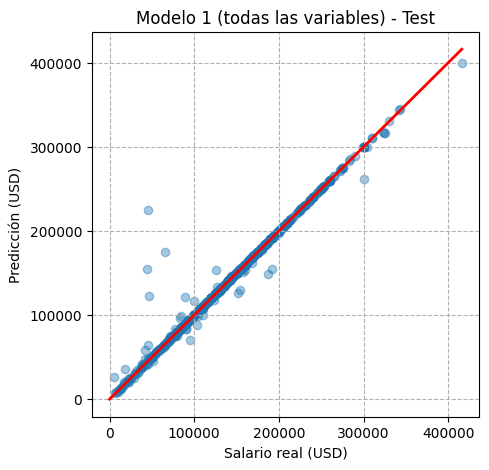

In [ ]:
#Hacemos las predicciones en test:
y_pred = pipe.predict(X_test)

#Graficamos
fig, ax = plt.subplots(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.4)
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="r", linewidth=2)
plt.xlabel("Salario real (USD)")
plt.ylabel("Predicción (USD)")
plt.title("Modelo 1 (todas las variables) - Test")
plt.grid(True, ls="--")
plt.show()

In [ ]:
#Calculamos las Metricas:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:,.1f} USD")
print(f"RMSE : {rmse:,.1f} USD")

R²   : 0.9761
MAE  : 1,497.2 USD
RMSE : 9,914.0 USD


Un R² de 0.9761 para predecir un salario a partir de datos de un puesto de trabajo es demasiado bueno. Con un MAE de apenas ~1.500 USD el modelo prácticamente "adivina" el salario exacto en la mayoría de los casos. Esto es muy llamativo, y es exactamente el tipo de cosa que conviene mirar con más cuidado.

## 3. Diagnóstico global: Permutation Feature Importance (PFI)

Calculamos PFI permutando cada variable original (no las columnas dummy), usando el pipeline completo, y midiendo la caída de R² en test.

In [ ]:
result = permutation_importance(
    pipe, X_test, y_test,
    scoring="r2", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

pfi = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std,
}).sort_values("importance_mean", ascending=False)

pfi

,feature,importance_mean,importance_std
4,salary,1.833043,0.099495
5,salary_currency,0.298485,0.024250
6,employee_residence,0.001599,0.000395
8,company_location,0.001345,0.000297
0,work_year,0.001075,0.000344
9,company_size,0.000776,0.000337
7,remote_ratio,0.000139,0.000605
1,experience_level,0.000101,0.000220
2,employment_type,0.000033,0.000144
3,job_title,-0.002200,0.000244


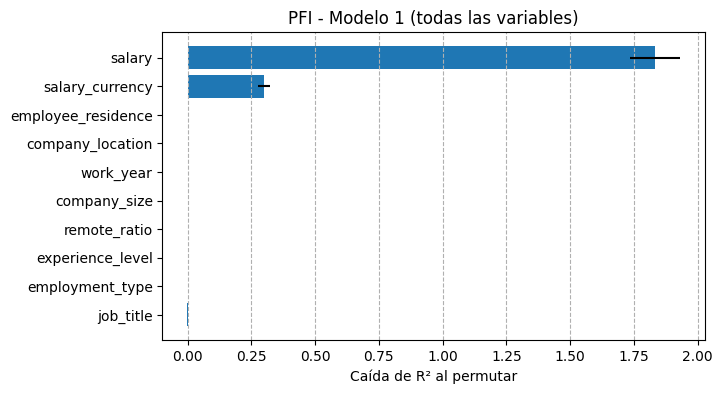

In [ ]:
plt.figure(figsize=(7, 4))
plt.barh(pfi["feature"], pfi["importance_mean"], xerr=pfi["importance_std"])
plt.xlabel("Caída de R² al permutar")
plt.title("PFI - Modelo 1 (todas las variables)")
plt.gca().invert_yaxis()
plt.grid(axis="x", ls="--")
plt.show()

Esto confirma la sospecha. `salary` tiene una importancia de 1.83 y `salary_currency` le sigue con 0.29. El resto de las variables tienen importancias del orden de 0.001-0.00003, es decir, prácticamente irrelevantes para el modelo.

Esto no es razonable si lo que uno espera es "qué determina el salario en USD de un puesto de Data Science" (seniority, rol, país, tamaño de empresa, modalidad remota). Que dos variables dominen de esa manera, y que sean justamente `salary` y `salary_currency`, es una señal fuerte de que hay algo raro pasando.

## 4. Diagnóstico local: SHAP

Para elegir las dos observaciones, en vez de tomar al azar, miramos el error de cada predicción en el set de test: elegimos el caso con el error más chico y el caso con el error más grande

In [ ]:
errores = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred,
    "error_abs": np.abs(y_test.values - y_pred),
}, index=X_test.index)

errores.describe()

,y_test,y_pred,error_abs
count,751.000000,751.000000,751.000000
mean,139807.580559,140288.096085,1497.210679
std,64168.203230,63428.019345,9806.789324
min,5409.000000,7806.520000,0.000000
25%,95000.000000,97987.170000,0.000000
50%,135000.000000,136000.000000,8.000000
75%,179100.000000,177831.850000,153.920000
max,416000.000000,399310.170000,179450.870000


In [ ]:
idx_chico = errores["error_abs"].idxmin()
idx_grande = errores["error_abs"].idxmax()

print("Caso con error chico:")
display(pd.concat([X_test.loc[[idx_chico]], errores.loc[[idx_chico]]], axis=1))

print("\nCaso con error grande:")
display(pd.concat([X_test.loc[[idx_grande]], errores.loc[[idx_grande]]], axis=1))

Caso con error chico:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size,y_test,y_pred,error_abs
3173,2022,SE,FT,Data Engineer,155000,USD,US,100,US,M,155000,155000.0,0.0



Caso con error grande:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size,y_test,y_pred,error_abs
3699,2020,EN,FT,AI Scientist,300000,DKK,DK,50,DK,S,45896,225346.87,179450.87


In [ ]:
preprocessor_fit = pipe.named_steps["preprocessor"]
rf_model = pipe.named_steps["model"]

feature_names = [
    name.replace("cat__", "").replace("num__", "")
    for name in preprocessor_fit.get_feature_names_out()
]

X_test_trans = pd.DataFrame(preprocessor_fit.transform(X_test).toarray(),
                            columns=feature_names,
                            index=X_test.index)

# nos quedamos solo con las 2 filas ANTES de llamar al explainer
filas_a_explicar = X_test_trans.loc[[idx_chico, idx_grande]]

explainer = shap.TreeExplainer(rf_model)
shap_explanation = explainer(filas_a_explicar)

### Caso 1: error chico

--- Caso 1: Error chico (idx=3173) | y_real=155000  y_pred=155000.0 ---


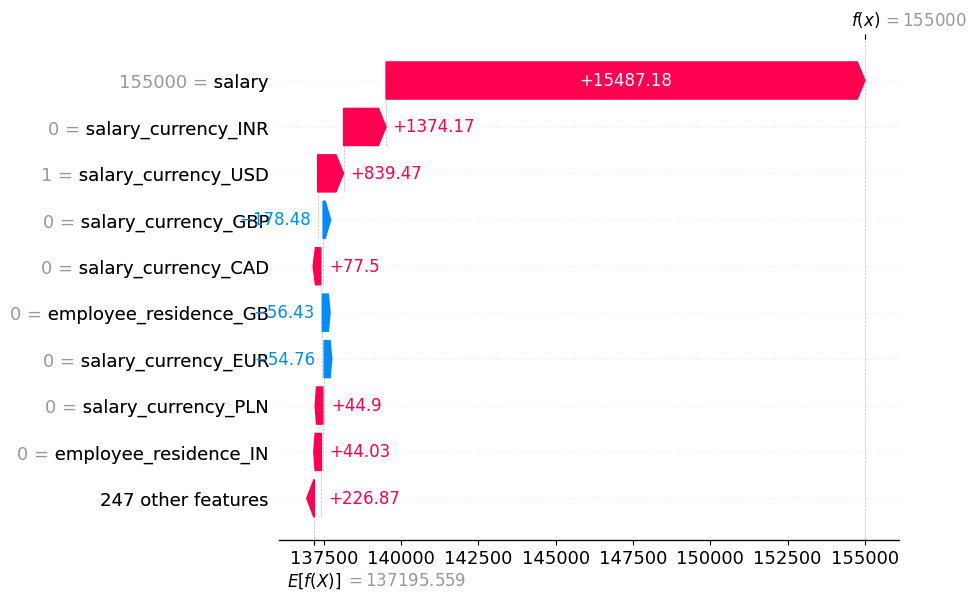

In [ ]:
print(f"--- Caso 1: Error chico (idx={idx_chico}) | y_real={y_test.loc[idx_chico]}  y_pred={y_pred[X_test.index.get_loc(idx_chico)]:.1f} ---")
shap.plots.waterfall(shap_explanation[0], max_display=10)

Acá `salary` es la variable que más empuja la predicción hacia arriba (+15.487) , y el hecho de que la moneda sea USD suma otro poco (+839). El resto de las variables aportan cantidades chicas. El modelo básicamente reproduce el valor de `salary` cuando la moneda ya es dólares, que es exactamente lo que uno haría a mano en ese caso (si ya está en USD, `salary_in_usd` es igual a `salary`). Coherente con el PFI: la variable que más pesa localmente es la misma que más pesa globalmente.

### Caso 2: error grande

--- Caso 2: Error grande (idx=3699) | y_real=45896  y_pred=225346.9 ---


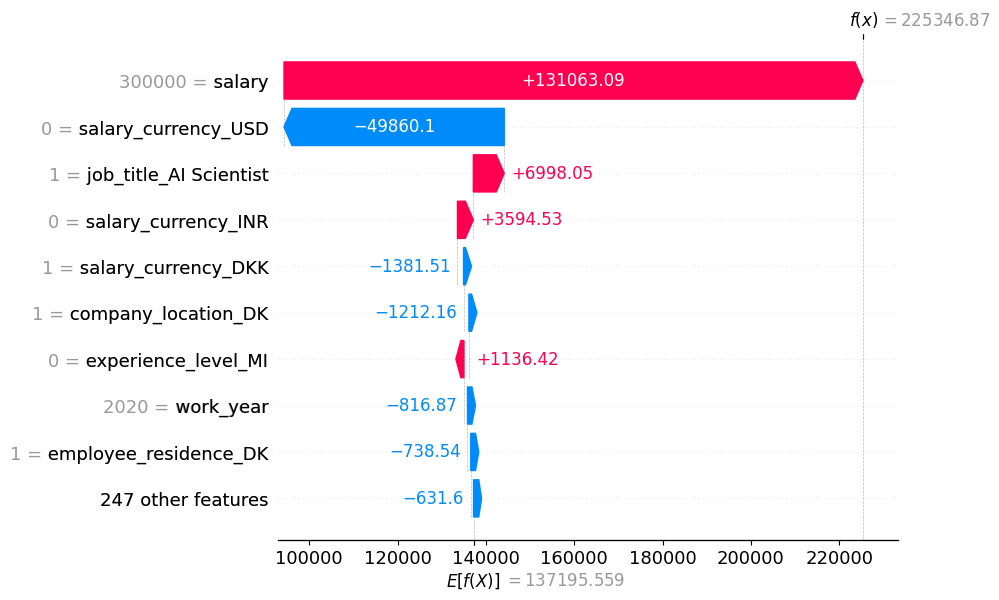

In [ ]:
print(f"--- Caso 2: Error grande (idx={idx_grande}) | y_real={y_test.loc[idx_grande]}  y_pred={y_pred[X_test.index.get_loc(idx_grande)]:.1f} ---")
shap.plots.waterfall(shap_explanation[1], max_display=10)

SHAP muestra que `salary` empuja la predicción fuerte hacia arriba (+131.063). `salary_currency_USD = 0` corrige hacia abajo (−49.860), y ser específicamente `DKK` suma un ajuste menor (−1.382), igual que `company_location_DK` (−1.212). Van en la dirección correcta, pero se quedan cortos: 300.000 DKK equivalen a ~46.000 USD reales en 2020, muy lejos de los ~225.000 predichos.

`job_title_AI Scientist` también aporta un empujón propio (+6.998), reflejando que el modelo reconoce ese rol como bien pago más allá del problema de moneda.

En síntesis: el modelo depende casi exclusivamente de `salary`, y como `DKK` está poco representado en los datos, la corrección por moneda no alcanza a compensar la brecha real de conversión.

## 5. Auditoría

### Hallazgo 1: Data leakage vía `salary` y `salary_currency`

- **Evidencia de las técnicas de interpretabilidad:** PFI ubica a `salary` (importancia = 1.83) y `salary_currency` (0.29) muy por encima de cualquier otra variable (todas por debajo de 0.001). SHAP confirma lo mismo a nivel local: en los dos casos analizados, `salary` es la variable que más mueve la predicción, y por lejos.
- **Causa probable:** `salary_in_usd` es, en la enorme mayoría de los casos, una transformación de `salary` y `salary_currency`. De hecho, en el dataset la mayoria de los registros ya están en USD (`salary_currency == "USD"`), y en esos casos `salary_in_usd` es *exactamente* igual a `salary`. Es decir, estamos dándole al modelo, disfrazada de "feature", una variable que contiene casi toda la información del target. Esto es un caso de data leakage.
- **Acción a tomar:** eliminaremos `salary` y `salary_currency` del conjunto de variables y reentrenamos el modelo, comparando performance e importancias.

### Hallazgo 2: Redundancia entre `employee_residence` y `company_location`

In [ ]:
coinciden = (df["employee_residence"] == df["company_location"]).mean()
print(f"Proporción de filas donde employee_residence == company_location: {coinciden:.1%}")

print("Casos donde son distintos:")
mismatch = df[df["employee_residence"] != df["company_location"]]
mismatch[["employee_residence", "company_location"]].value_counts().head(6)

Proporción de filas donde employee_residence == company_location: 97.4%
Casos donde son distintos:


,,count
employee_residence,company_location,
IN,US,7
ES,US,3
BR,US,3
BO,US,2
AR,US,2
PK,DE,2


- **Evidencia:** `employee_residence` y `company_location` coinciden en el 97.4% de las filas: son, en la práctica, casi la misma variable.
- **Causa probable:** en la gran mayoría de los puestos el empleado reside en el mismo país donde está la empresa. Tiene sentido, incluso con trabajo remoto suele haber restricciones legales/impositivas para contratar en otro país.
- **Acción:** no es leakage (ninguna de las dos contiene el target de forma directa), pero para un análisis más limpio convendría no interpretar la importancia baja de alguna de estas dos variables como "no importa", y evaluar quedarse con una sola de las dos variables (o combinarlas) si el objetivo fuera cuantificar con precisión el efecto de la ubicación.

## 6. Corrección del leakage: reentrenamiento sin `salary` ni `salary_currency`


In [ ]:
X2 = df.drop(columns=[target, "salary", "salary_currency"])
y2 = df[target]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE
)

categorical_features_2 = ["experience_level", "employment_type", "job_title",
                           "employee_residence", "company_location", "company_size"]
numeric_features_2 = ["work_year", "remote_ratio"]


preprocessor_2 = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_2),
    ("num", "passthrough", numeric_features_2),
])

model_2 = RandomForestRegressor(random_state=RANDOM_STATE)
pipe_2 = Pipeline([("preprocessor", preprocessor_2), ("model", model_2)])
pipe_2.fit(X2_train, y2_train)

y2_pred = pipe_2.predict(X2_test)

r2_2 = r2_score(y2_test, y2_pred)
mae_2 = mean_absolute_error(y2_test, y2_pred)
rmse_2 = np.sqrt(mean_squared_error(y2_test, y2_pred))

print("Comparación de performance")
print(f"{'':15s}{'R²':>10s}{'MAE':>14s}{'RMSE':>14s}")
print(f"{'Modelo 1':15s}{r2:10.4f}{mae:14,.0f}{rmse:14,.0f}")
print(f"{'Modelo 2':15s}{r2_2:10.4f}{mae_2:14,.0f}{rmse_2:14,.0f}")

Comparación de performance
                       R²           MAE          RMSE
Modelo 1           0.9761         1,497         9,914
Modelo 2           0.4338        35,845        48,250


La comparación confirma lo que veníamos sospechando: al sacar `salary` y `salary_currency`, el R² se desploma de 0.976 a 0.434, y el MAE pasa de ~1.500 a 35.845 USD. La performance casi perfecta del Modelo 1 dependía casi por completo del leakage, no de que el modelo entienda qué determina realmente el salario. Un R² de 0.43 es mucho más creíble para este problema: predecir compensación a partir de rol, experiencia y ubicación es bastante más difícil que "copiar" el salario nominal.

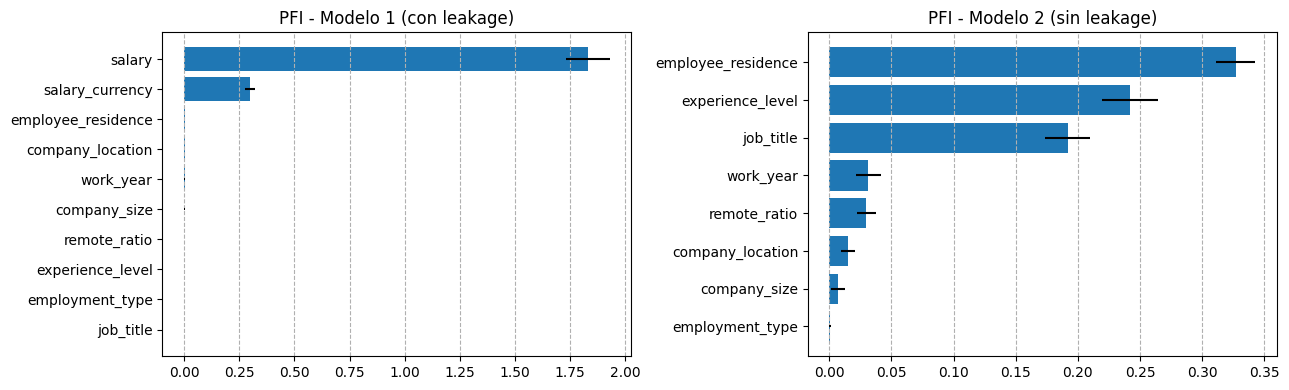

,feature,importance_mean,importance_std
4,employee_residence,0.326781,0.016037
1,experience_level,0.242092,0.022399
3,job_title,0.191789,0.018148
0,work_year,0.031341,0.010172
5,remote_ratio,0.029686,0.007765
6,company_location,0.014766,0.005574
7,company_size,0.006904,0.005731
2,employment_type,0.000506,0.000562


In [ ]:
result_2 = permutation_importance(
    pipe_2, X2_test, y2_test,
    scoring="r2", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

pfi_2 = pd.DataFrame({
    "feature": X2_test.columns,
    "importance_mean": result_2.importances_mean,
    "importance_std": result_2.importances_std,
}).sort_values("importance_mean", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].barh(pfi["feature"], pfi["importance_mean"], xerr=pfi["importance_std"])
axes[0].set_title("PFI - Modelo 1 (con leakage)")
axes[0].invert_yaxis()
axes[0].grid(axis="x", ls="--")

axes[1].barh(pfi_2["feature"], pfi_2["importance_mean"], xerr=pfi_2["importance_std"])
axes[1].set_title("PFI - Modelo 2 (sin leakage)")
axes[1].invert_yaxis()
axes[1].grid(axis="x", ls="--")

plt.tight_layout()
plt.show()

pfi_2

Con el leakage afuera, el ranking de importancia pasa a tener sentido de negocio: `employee_residence` (0.327), `experience_level` (0.242) y `job_title` (0.192) son las variables más relevantes, muy por encima del resto. `work_year` y `remote_ratio` aportan bastante menos (~0.03 cada una), y `company_location`, `company_size` y `employment_type` quedan casi sin peso.

Tiene sentido: la experiencia y el rol son razonablemente los factores más directos de la compensación, y el país de residencia también pesa fuerte porque hay mercados laborales con niveles salariales muy distintos. Que `employment_type` tenga importancia prácticamente nula (0.0005) también es coherente, ya que la gran mayoría de los registros son full-time y esa variable casi no varía.

In [ ]:
preprocessor_2_fit = pipe_2.named_steps["preprocessor"]
rf_model_2 = pipe_2.named_steps["model"]

feature_names_2 = [
    name.replace("cat__", "").replace("num__", "")
    for name in preprocessor_2_fit.get_feature_names_out()
]

X2_test_trans = pd.DataFrame(
    preprocessor_2_fit.transform(X2_test).toarray(),
    columns=feature_names_2,
    index=X2_test.index,
)

# nos quedamos solo con las 2 filas ANTES de llamar al explainer
filas_a_explicar2 = X2_test_trans.loc[[idx_chico, idx_grande]]

explainer_2 = shap.TreeExplainer(rf_model_2)
shap_explanation_2 = explainer_2(filas_a_explicar2)

--- Caso 1: Error chico (idx=3173) | y_real=155000  y_pred=158248.3 ---


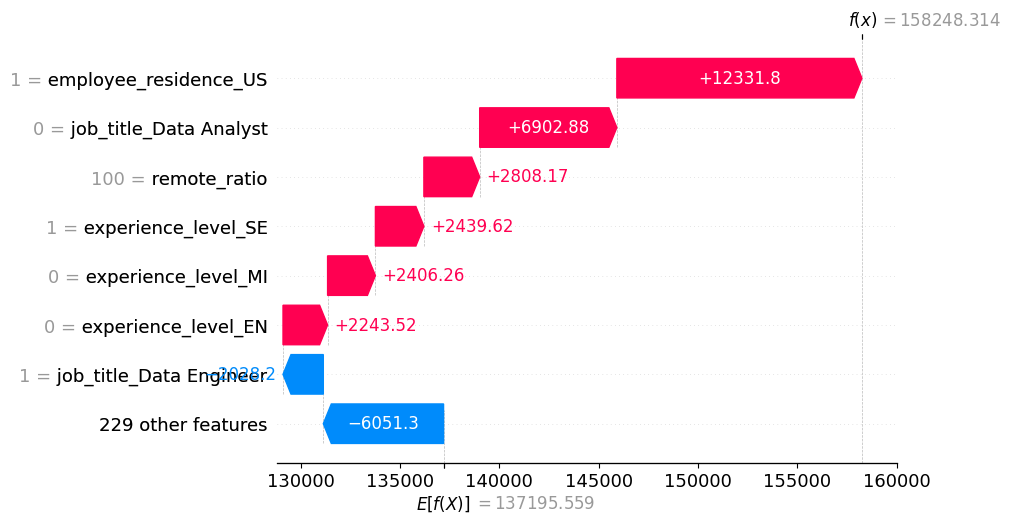

In [ ]:
print(f"--- Caso 1: Error chico (idx={idx_chico}) | y_real={y2_test.loc[idx_chico]}  y_pred={y2_pred[X2_test.index.get_loc(idx_chico)]:.1f} ---")
shap.plots.waterfall(shap_explanation_2[0], max_display=8)


Ahora el error ya no es cero (155.000 real vs 158.248 predicho, error ≈3.250). `employee_residence_US = 1` es lo que más empuja hacia arriba (+12.332), seguido de no ser `job_title_Data Analyst` (+6.903) y del seniority `SE` (+2.440). Tiene sentido: reside en EE.UU., es senior, y esas dos cosas solas ya explican buena parte de un salario alto.

--- Caso 2: Error grande (idx=3699) | y_real=45896  y_pred=35516.8 ---


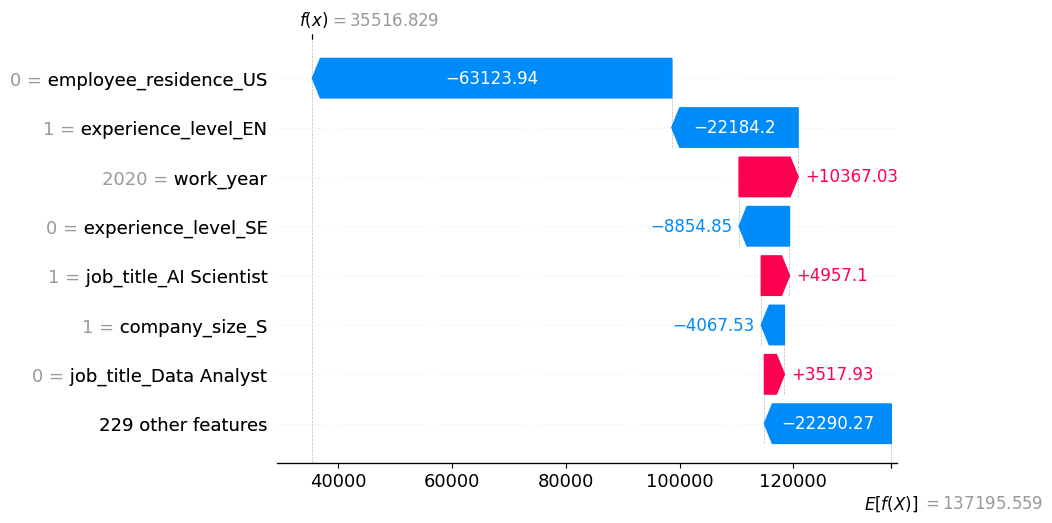

In [ ]:
print(f"--- Caso 2: Error grande (idx={idx_grande}) | y_real={y2_test.loc[idx_grande]}  y_pred={y2_pred[X2_test.index.get_loc(idx_grande)]:.1f} ---")
shap.plots.waterfall(shap_explanation_2[1], max_display=8)


Acá está la sorpresa — el error baja fuerte, de ~180.000 (Modelo 1) a solo ~10.379 (45.896 real vs 35.517 predicho). `employee_residence_US = 0` es la variable que más pesa, y empuja fuerte hacia abajo (−63.124), junto con `experience_level_EN = 1` (−22.184) y no ser `SE` (−8.855). Sin `salary`/`salary_currency` de por medio, el modelo se apoya en señales genuinas (país, seniority, tamaño de empresa) y termina bastante más cerca del valor real.

Confirma lo que veníamos viendo en la auditoría: el leakage no solo inflaba las métricas agregadas, también hacía que el modelo fallara peor en los casos con monedas poco representadas. Sacándolo, esos mismos casos, mejoran la prediccion.

El ejercicio deja una lección clara: un R² alto no es sinónimo de un buen modelo, y las técnicas de interpretabilidad (PFI y SHAP) fueron las que permitieron detectar que el modelo 1 no estaba aprendiendo nada sobre qué determina el salario, sino que estaba explotando una relación casi determinística entre dos columnas del propio dataset.